# 🚢 Titanic Survival Prediction

## Machine Learning Classification Project

This project explores the Titanic dataset to analyze passenger survival patterns and build machine learning models capable of predicting survival outcomes.

The project follows a professional Data Science workflow including:

- Data Cleaning
- Feature Engineering
- Exploratory Data Analysis (EDA)
- Logistic Regression
- Random Forest
- Model Evaluation
- Feature Importance Analysis

---

## Technologies Used

- Python
- Pandas
- Matplotlib
- Seaborn
- Scikit-learn
- Jupyter Notebook

---

## Project Goal

The goal is not only to build predictive models, but also to understand the relationships between passenger characteristics and survival probability.

In [1]:
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

from data.load_data import cargar_datos
from data.clean_data import revisar_nulos, imputar_datos

from features.build_features import (
    agregar_tamano_familia,
    agregar_is_alone,
    agregar_title
)

from visualization.plots import (
    plot_survival_by_family,
    plot_survival_by_sex,
    plot_survival_by_class,
    plot_age_distribution,
    plot_age_boxplot,
    plot_correlation_heatmap,
    plot_feature_importance
)

from models.train_model import entrenar_modelo
from models.random_forest_model import entrenar_random_forest
from models.evaluate_model import evaluar_modelo
from models.pipeline_model import entrenar_pipeline
from models.model_io import guardar_modelo , cargar_modelo
from models.tune_random_forest import optimizar_random_forest

from config import RANDOM_FOREST_MODEL_PATH, RANDOM_STATE , PIPELINE_MODEL_PATH
from sklearn.ensemble import RandomForestClassifier

from inference.predictor import predecir_pasajero

# Load Dataset

In [2]:
df = cargar_datos('../data/titanic.csv')

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# Dataset Overview

Before cleaning and modeling the data, it is important to understand:

- Dataset dimensions
- Data types
- Missing values
- General structure

In [3]:
print(f'Rows: {df.shape[0]}')
print(f'Columns: {df.shape[1]}')

Rows: 891
Columns: 12


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [5]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
revisar_nulos(df)

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

# 🧹 Data Cleaning

The dataset contains missing values in several variables.

Cleaning strategy:

- `Age` → median imputation
- `Embarked` → mode imputation
- `Cabin` → removed due to excessive missing values

In [7]:
df = imputar_datos(df)

In [8]:
revisar_nulos(df)

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

# Feature Engineering


Feature engineering is the process of creating new variables from existing data in order to provide additional information to machine learning models.

Previous experiments showed that changing algorithms and tuning hyperparameters produced only limited improvements. Therefore, the focus shifted toward creating more informative features.

Three new features were engineered:

## FamilySize

`FamilySize` represents the total number of family members traveling together, including the passenger.

It is calculated as:

```python
FamilySize = SibSp + Parch + 1
```

where:

- `SibSp` = number of siblings/spouses aboard
- `Parch` = number of parents/children aboard
- `+1` accounts for the passenger themselves

**Hypothesis:**

Passengers traveling with family members may have had different survival probabilities compared to passengers traveling alone.

---

## IsAlone

`IsAlone` is a binary feature derived from `FamilySize`.

- `IsAlone = 1` if `FamilySize == 1`
- `IsAlone = 0` if `FamilySize > 1`

**Hypothesis:**

Passengers traveling alone may have experienced different survival outcomes compared to those traveling with relatives.

---

## Title

`Title` is extracted from the passenger's name and represents their social title.

Examples include:

- Mr
- Mrs
- Miss
- Master

Rare titles are grouped into a single category called `Rare`.

**Hypothesis:**

Titles may capture information related to age, gender, social status, and family role, all of which could influence survival probability.


In [9]:
df = agregar_tamano_familia(df)
df = agregar_is_alone(df)
df = agregar_title(df)

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,FamilySize,IsAlone,Title
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,2,0,Mr
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,2,0,Mrs
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,1,1,Miss
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,2,0,Mrs
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,1,1,Mr


# Feature Engineering Analysis

## Objective

The objective of this phase was to determine whether the newly engineered features could provide additional predictive information about passenger survival.

Previous experiments showed that changing algorithms and tuning hyperparameters produced only marginal improvements. Therefore, the focus shifted toward improving the quality of the input features.

---

## Analysis of Title

Survival rate by title:

| Title | Survival Rate |
|--------|--------------:|
| Mrs | 79.2% |
| Miss | 69.8% |
| Master | 57.5% |
| Rare | 44.4% |
| Mr | 15.7% |

### Observation

Strong differences were observed between passenger titles. In particular, passengers with the title **Mr** showed a much lower survival rate compared to **Mrs** and **Miss**.

This suggests that `Title` contains highly informative signals related to survival.

---

## Analysis of IsAlone

Survival rate by IsAlone:

| IsAlone | Survival Rate |
|----------|--------------:|
| 0 | 50.6% |
| 1 | 30.4% |

### Observation

Passengers traveling with others had substantially higher survival rates than passengers traveling alone.

This indicates that `IsAlone` may contribute useful predictive information.

---

## Impact on Logistic Regression

After incorporating the new features:

- Accuracy remained approximately **0.80**.
- Recall for the survived class increased from **0.70** to **0.74**.
- F1-score increased slightly.

### Observation

Although overall accuracy did not change significantly, the model became better at identifying passengers who survived.

---

## Impact on Random Forest

After incorporating the new features:

- Accuracy increased to approximately **0.82**.
- Recall for the survived class increased to **0.80**.

### Observation

The engineered features provided additional information that improved model performance.

---


## Feature Importance Findings

Top Random Forest features:

| Feature | Importance |
|----------|----------:|
| Fare | 0.275 |
| Age | 0.230 |
| Title_Mr | 0.140 |
| Sex_male | 0.125 |
| Pclass | 0.083 |
| FamilySize | 0.068 |
| Title_Mrs | 0.033 |
| Title_Miss | 0.022 |
| IsAlone | 0.013 |
| Title_Rare | 0.005 |

### Observation

`Title_Mr` became one of the most important variables in the model, confirming that passenger titles contain strong predictive information.

In contrast, `IsAlone` showed relatively low importance, suggesting that much of its information was already captured by `FamilySize`.

---

## Conclusions

The results confirm that feature engineering produced greater improvements than changing algorithms alone.

### Key Findings

- `Title` was the most successful engineered feature.
- `IsAlone` contained useful information but contributed less than expected.
- Random Forest benefited more from the new features than Logistic Regression.
- Feature engineering proved to be a more effective strategy than additional hyperparameter tuning at this stage of the project.
- The performance improvements validated the importance of understanding the data before trying more complex algorithms.

# Exploratory Data Analysis (EDA)

## Survival Rate by Family Size

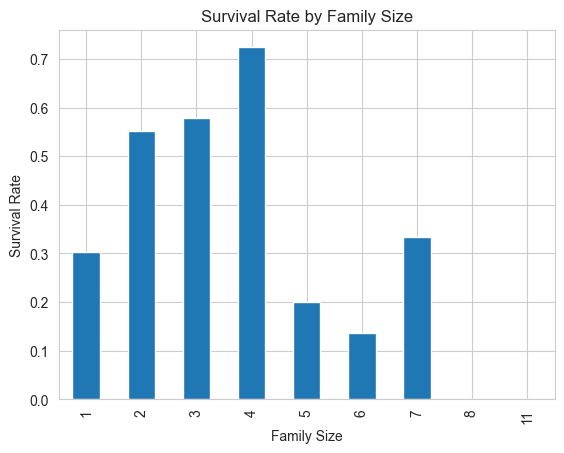

In [10]:
plot_survival_by_family(df)

### Observation

Passengers traveling with small families showed different survival patterns compared to passengers traveling alone or in large groups.

## Survival Rate by Sex

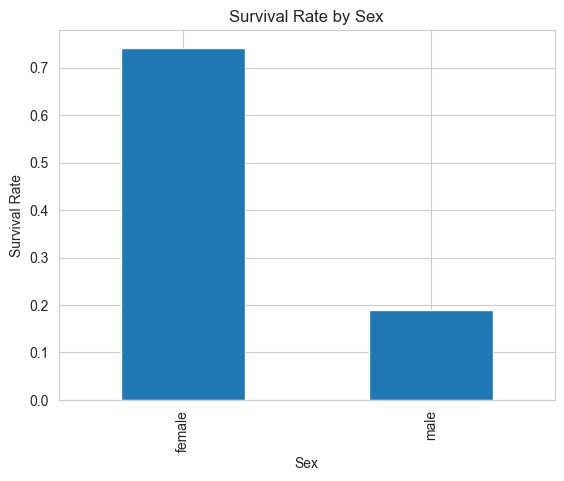

In [11]:
plot_survival_by_sex(df)

### Insight

Female passengers had a significantly higher survival rate compared to male passengers.

This suggests that sex is likely one of the strongest predictive variables in the dataset.

## Survival Rate by Passenger Class

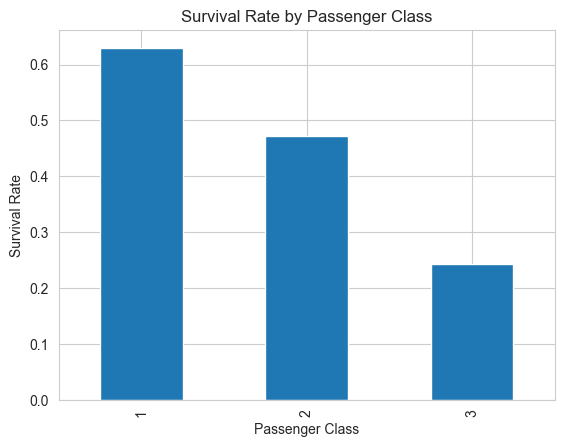

In [12]:
plot_survival_by_class(df)

### Insight

Passengers traveling in higher classes had greater survival probabilities.

This may reflect differences in cabin location, access to lifeboats, or social priority during evacuation.

## Survival Rate by Family Size

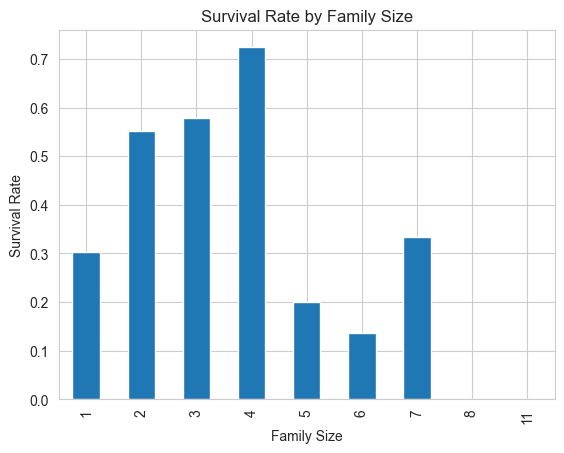

In [13]:
plot_survival_by_family(df)

### Insight

Passengers traveling in very large groups or completely alone appeared to have lower survival rates.

## Age Distribution

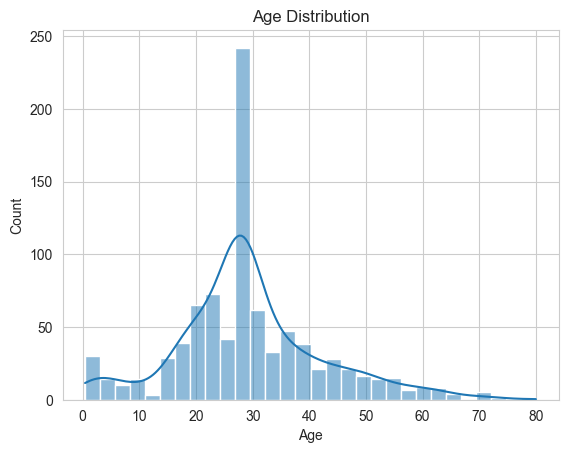

In [14]:
plot_age_distribution(df)

### Insight

Most passengers were concentrated in young adult age ranges, with fewer elderly passengers represented in the dataset.

## Age Boxplot

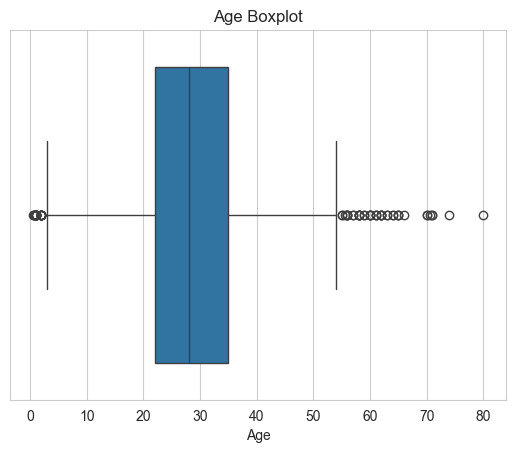

In [15]:
plot_age_boxplot(df)

### Insight

The boxplot reveals the presence of several age outliers, particularly among older passengers.

## Correlation Heatmap

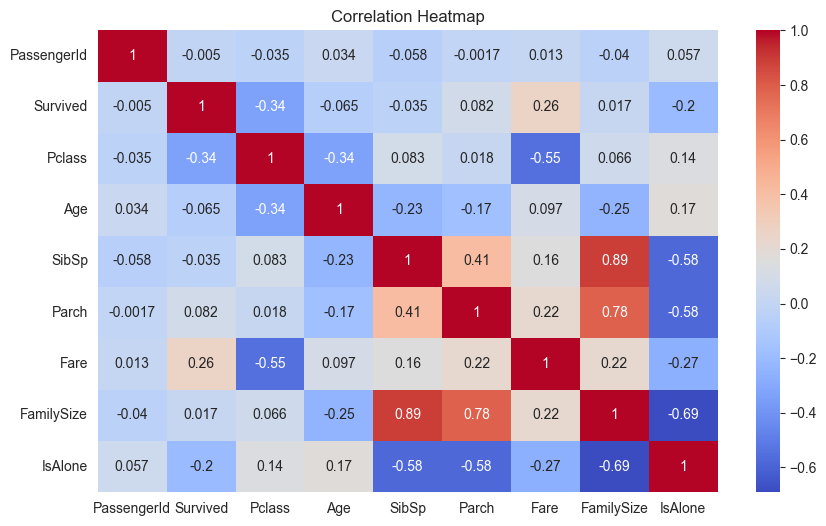

In [16]:
plot_correlation_heatmap(df)

### Insight

Variables such as passenger class, fare, and family size show meaningful relationships with survival probability.

# Logistic Regression Model

Logistic Regression is used as a baseline classification model.

This model is:
- Fast
- Interpretable
- Commonly used for binary classification

In [17]:
lr_model, lr_y_test, lr_predictions = entrenar_modelo(df)

Accuracy: 0.8044692737430168


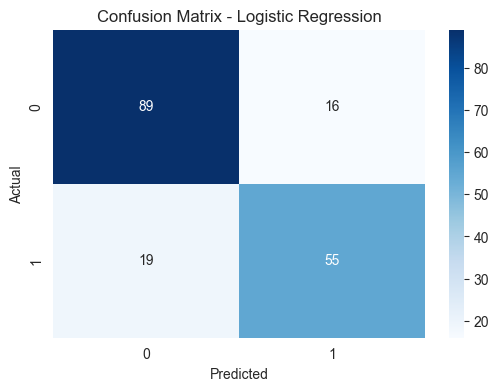

=== Classification Report: Logistic Regression ===
              precision    recall  f1-score   support

           0       0.82      0.85      0.84       105
           1       0.77      0.74      0.76        74

    accuracy                           0.80       179
   macro avg       0.80      0.80      0.80       179
weighted avg       0.80      0.80      0.80       179



In [18]:
evaluar_modelo(
    lr_y_test,
    lr_predictions,
    model_name="Logistic Regression"
)

In [19]:
# 1. Extraer los coeficientes
coeficientes = lr_model.coef_[0]

# 2. Crear un DataFrame para mapear variable con su coeficiente
importancia_lr = pd.DataFrame({
    'Feature': lr_model.feature_names_in_,
    'Coeficiente': lr_model.coef_[0]
}).sort_values(by='Coeficiente', ascending=False)

print("=== COEFICIENTES DE REGRESIÓN LOGÍSTICA ===")
print(importancia_lr)

=== COEFICIENTES DE REGRESIÓN LOGÍSTICA ===
      Feature  Coeficiente
8   Title_Mrs     0.480763
2        Fare     0.004982
1         Age    -0.027547
4     IsAlone    -0.345217
3  FamilySize    -0.486974
6  Title_Miss    -0.611954
0      Pclass    -0.838575
5    Sex_male    -1.002631
9  Title_Rare    -1.207310
7    Title_Mr    -2.280055


### Model Interpretation

The Logistic Regression model achieved solid performance and provided a strong baseline for future model comparisons.

# Random Forest Model

Random Forest is an ensemble learning algorithm that combines multiple decision trees.

Advantages:
- Handles non-linear relationships
- Reduces overfitting
- Often performs well on tabular datasets

In [20]:
rf_model, X, rf_y_test, rf_predictions = entrenar_random_forest(df)

Random Forest Accuracy: 0.8212290502793296


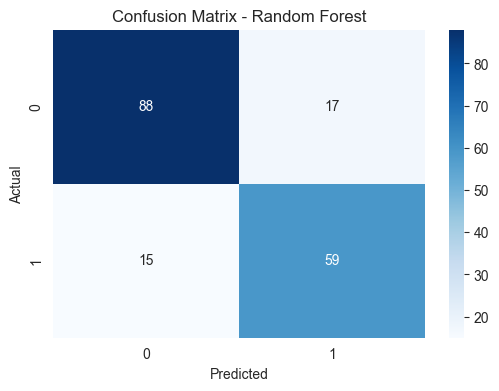

=== Classification Report: Random Forest ===
              precision    recall  f1-score   support

           0       0.85      0.84      0.85       105
           1       0.78      0.80      0.79        74

    accuracy                           0.82       179
   macro avg       0.82      0.82      0.82       179
weighted avg       0.82      0.82      0.82       179



In [21]:
evaluar_modelo(
    rf_y_test,
    rf_predictions,
    model_name="Random Forest"
)

### Model Interpretation

Random Forest improved predictive flexibility and captured more complex interactions between variables.

# Feature Importance

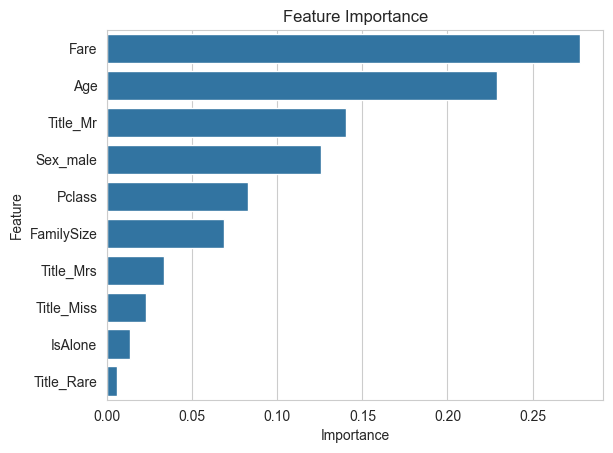

In [22]:
plot_feature_importance(rf_model, X)

### Insight

Feature importance analysis indicates that variables such as sex, fare, passenger class, and age strongly influenced model predictions.

# Pipeline Profesional con Scikit-Learn

In [23]:
rf = RandomForestClassifier(
    n_estimators=50,
    max_depth=5,
    min_samples_split=2,
    random_state=RANDOM_STATE
)

In [24]:
pipeline_model, X_test, y_test, predictions = entrenar_pipeline(df, rf)

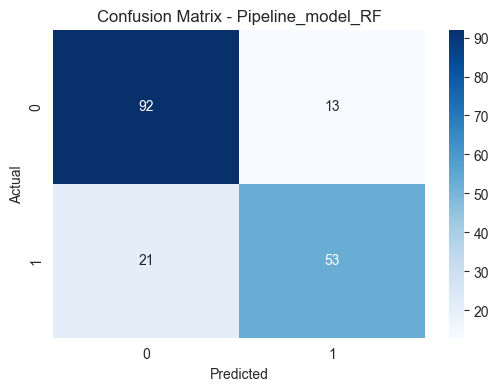

=== Classification Report: Pipeline_model_RF ===
              precision    recall  f1-score   support

           0       0.81      0.88      0.84       105
           1       0.80      0.72      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



In [25]:
evaluar_modelo(
    y_test,
    predictions,
    model_name="Pipeline_model_RF"
)

# Hyperparameter Tuning

Best Parameters:
{'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 50}
Best Score:
0.8370235398404413


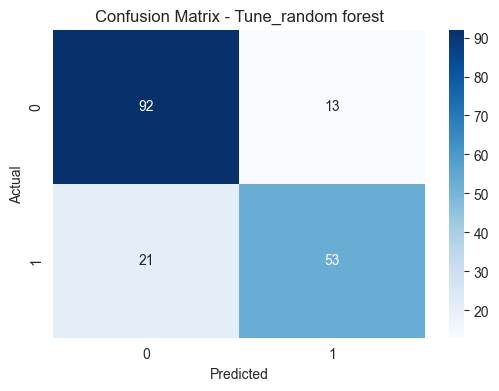

=== Classification Report: Tune_random forest ===
              precision    recall  f1-score   support

           0       0.81      0.88      0.84       105
           1       0.80      0.72      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



In [26]:
best_model, X_test_tuned, y_test_tuned = (
    optimizar_random_forest(df)
)

predictions_tuned = best_model.predict(X_test_tuned)

evaluar_modelo(
    y_test_tuned,
    predictions_tuned,
    model_name= "Tune_random forest"
)

# Selección del modelo final

After comparing the trained models, Random Forest was selected as the final model because it offered the best balance of Accuracy, Precision, Recall, and F1-score. Crucially, it yielded the highest Recall for the positive class (Survived). To prevent feature mismatch errors on new passenger data caused by standalone get_dummies preprocessing, we integrated the Random Forest model directly into our existing pipeline (replacing the previous linear regression model). The complete pipeline is now saved with the Random Forest model embedded.

# Guardar modelo entrenado

In [27]:
guardar_modelo(pipeline_model, PIPELINE_MODEL_PATH)

Modelo guardado en: C:\Users\ADOF_\Curso\Proyectos nuevos\mi_proyecto_titanic\models\pipeline.pkl


# Cargar modelo entrenado

In [28]:
modelo_cargado = cargar_modelo(PIPELINE_MODEL_PATH)

Modelo cargado desde: C:\Users\ADOF_\Curso\Proyectos nuevos\mi_proyecto_titanic\models\pipeline.pkl


In [29]:
modelo_cargado

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [30]:
del pipeline_model

In [31]:
pipeline_model

NameError: name 'pipeline_model' is not defined

In [32]:
predicciones = modelo_cargado.predict(X_test)

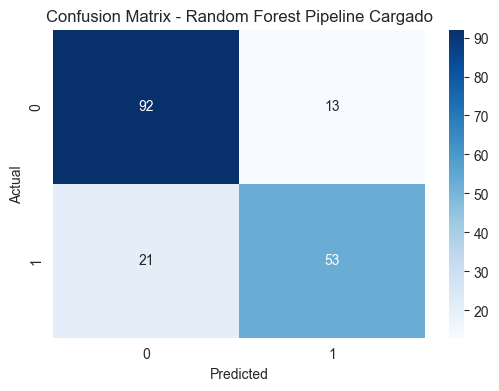

=== Classification Report: Random Forest Pipeline Cargado ===
              precision    recall  f1-score   support

           0       0.81      0.88      0.84       105
           1       0.80      0.72      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



In [33]:
evaluar_modelo(y_test, predicciones,model_name="Random Forest Pipeline Cargado")

# Creacion y prediccion de un nuevo pasajero 

In [34]:
prediccion, probabilidades = predecir_pasajero(
    modelo=modelo_cargado,
    name="Cumings, Mrs. John Bradley",
    pclass=1,
    sex="female",
    age=28,
    fare=85,
    sibsp=1,
    parch=0
)

In [35]:
if prediccion == 1:

    print("✅ El pasajero probablemente sobreviviría.")

else:

    print("❌ El pasajero probablemente no sobreviviría.")


print(f"Probabilidad de no sobrevivir: {probabilidades[0]:.2%}")

print(f"Probabilidad de sobrevivir: {probabilidades[1]:.2%}")

✅ El pasajero probablemente sobreviviría.
Probabilidad de no sobrevivir: 3.47%
Probabilidad de sobrevivir: 96.53%


# Final Conclusions

## Key Findings

- Female passengers had significantly higher survival rates.
- Passenger class strongly influenced survival probability.
- Feature engineering improved model usefulness.
- Logistic Regression provided a reliable baseline model.
- Random Forest captured more complex patterns and relationships.

---

## Technical Skills Demonstrated

This project demonstrates:

- Data Cleaning
- Exploratory Data Analysis
- Data Visualization
- Feature Engineering
- Machine Learning Classification
- Model Evaluation
- Feature Importance Analysis
- Modular Project Architecture
